# Notebook 4 - Three-Way Weight-Forensic Comparison (Benign vs Plain-LoRA vs SubLoRA)

**Purpose.** Compute the full weight-level forensic statistics for all three adapters on the SAME scale, so the paper's Section 6 can present an apples-to-apples table instead of a single aggregate score.

**Why this notebook exists.** Notebook 2 reported the full statistical battery (Frobenius, spectral entropy, KL/JS, Wilcoxon, KS, anomaly score) only for Plain-LoRA vs benign. Notebook 2 Section 11 added SubLoRA but printed only the aggregate adapter-level anomaly score (3.78). This notebook fills the gap: it recomputes every statistic for SubLoRA vs benign too.

**Cost.** Weight-only. No GPU, no model loading, no inference. Reads the saved adapter `.safetensors` files and does numpy/scipy math. Runs in seconds.

**Prerequisite.** Run this in the SAME project root where Notebooks 1-3 saved their artifacts, i.e. where these directories exist:
- `./models/benign_adapter/`
- `./models/malicious_adapter/`
- `./models/sublora_adapter_seed0/`  (and optionally seed1, seed2)

Outputs are written to `./results/tables/` and `./results/figures/`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy import stats
from safetensors.torch import load_file
import matplotlib.pyplot as plt

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy import stats
from safetensors.torch import load_file
import matplotlib.pyplot as plt

# ---- Locate the project root automatically ----
# Walk up from the current directory until we find a 'models' folder containing the adapters.
def find_project_root(start='.'):
    p = Path(start).resolve()
    for cand in [p, *p.parents]:
        if (cand / 'models' / 'benign_adapter').exists():
            return cand
    return Path('.').resolve()

ROOT = find_project_root()
print('Project root:', ROOT)

MODELS = ROOT / 'models'
RESULTS = ROOT / 'results'
TABLES = RESULTS / 'tables'
FIGS = RESULTS / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

ADAPTERS = {
    'Benign':     MODELS / 'benign_adapter',
    'Plain-LoRA': MODELS / 'malicious_adapter',
    'SubLoRA':    MODELS / 'sublora_adapter_seed0',
}
for name, path in ADAPTERS.items():
    print(f'{name:12s} -> {path}   exists={path.exists()}')

Project root: E:\ML Research\Lora paper\new paper
Benign       -> E:\ML Research\Lora paper\new paper\models\benign_adapter   exists=True
Plain-LoRA   -> E:\ML Research\Lora paper\new paper\models\malicious_adapter   exists=True
SubLoRA      -> E:\ML Research\Lora paper\new paper\models\sublora_adapter_seed0   exists=True


In [4]:
# ---- Load LoRA weights and reconstruct per-layer deltas  Delta W = B @ A ----
def load_lora_weights(adapter_dir):
    p = Path(adapter_dir)
    st = p / 'adapter_model.safetensors'
    if st.exists():
        return load_file(str(st))
    return torch.load(p / 'adapter_model.bin', map_location='cpu')

def layer_deltas(weights):
    """Return {layer_name: Delta W} for every LoRA-adapted matrix."""
    out = {}
    for k in weights:
        if 'lora_A' in k:
            b_key = k.replace('lora_A', 'lora_B')
            base = k.replace('.lora_A.weight', '').replace('.lora_A.default.weight', '')
            if b_key in weights:
                A = weights[k].float()
                B = weights[b_key].float()
                out[base] = (B @ A).cpu()
    return out

deltas = {name: layer_deltas(load_lora_weights(path)) for name, path in ADAPTERS.items()}

common = sorted(set.intersection(*[set(d.keys()) for d in deltas.values()]))
print(f'Layers common to all three adapters: {len(common)}')
print('Example layer:', common[0], '| shape:', tuple(deltas["Benign"][common[0]].shape))

Layers common to all three adapters: 112
Example layer: base_model.model.model.layers.0.self_attn.k_proj | shape: (256, 1536)


In [5]:
# ---- Per-layer statistics: Frobenius norm and singular-value spectral entropy ----
def spectral_entropy(dw):
    sv = torch.linalg.svdvals(dw).float().numpy()
    sv = sv[sv > 0]
    p = sv / sv.sum()
    return float(-(p * np.log(p)).sum())

frob = {name: np.array([float(deltas[name][k].norm()) for k in common]) for name in ADAPTERS}
sent = {name: np.array([spectral_entropy(deltas[name][k]) for k in common]) for name in ADAPTERS}

print('Mean Frobenius norm per layer:')
for name in ADAPTERS:
    print(f'  {name:12s}  {frob[name].mean():.4f}')
print('Mean spectral entropy per layer:')
for name in ADAPTERS:
    print(f'  {name:12s}  {sent[name].mean():.4f}')

Mean Frobenius norm per layer:
  Benign        0.2839
  Plain-LoRA    0.4683
  SubLoRA       0.4245
Mean spectral entropy per layer:
  Benign        2.5019
  Plain-LoRA    2.4296
  SubLoRA       2.1062


In [6]:
# ---- Full statistical battery: each malicious adapter vs the benign baseline ----
def cohens_d_paired(a, b):
    diff = np.asarray(a, float) - np.asarray(b, float)
    return float(diff.mean() / diff.std(ddof=1))

def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    gt = sum(x > y for x in a for y in b)
    lt = sum(x < y for x in a for y in b)
    return float((gt - lt) / (len(a) * len(b)))

def kl_div(p, q, eps=1e-12):
    p = p + eps; q = q + eps
    p = p / p.sum(); q = q / q.sum()
    return float((p * np.log(p / q)).sum())

def js_divergence(a_vals, b_vals, bins=200):
    lo = float(min(a_vals.min(), b_vals.min()))
    hi = float(max(a_vals.max(), b_vals.max()))
    if lo == hi:
        return 0.0
    pa, _ = np.histogram(a_vals, bins=bins, range=(lo, hi), density=True)
    pb, _ = np.histogram(b_vals, bins=bins, range=(lo, hi), density=True)
    pa = pa / max(pa.sum(), 1e-12); pb = pb / max(pb.sum(), 1e-12)
    m = 0.5 * (pa + pb)
    return 0.5 * kl_div(pa, m) + 0.5 * kl_div(pb, m)

def battery_vs_benign(name):
    fb, fm = frob['Benign'], frob[name]
    sb, sm = sent['Benign'], sent[name]
    w_stat, w_p = stats.wilcoxon(fb, fm)
    u_stat, u_p = stats.mannwhitneyu(fb, fm, alternative='two-sided')
    se_w, se_p = stats.wilcoxon(sb, sm)
    b_all = np.concatenate([deltas['Benign'][k].numpy().ravel() for k in common])
    m_all = np.concatenate([deltas[name][k].numpy().ravel() for k in common])
    # per-layer KL and JS divergence on matched value-histograms
    kls, jss = [], []
    for k in common:
        a = deltas['Benign'][k].numpy().ravel()
        b = deltas[name][k].numpy().ravel()
        rng = (min(a.min(), b.min()), max(a.max(), b.max()))
        pa, _ = np.histogram(a, bins=200, range=rng, density=True)
        pb, _ = np.histogram(b, bins=200, range=rng, density=True)
        kls.append(kl_div(pa, pb))
        jss.append(js_divergence(a, b))
    ks_d, ks_p = stats.ks_2samp(b_all, m_all)
    return {
        'adapter': name,
        'mean_frobenius': float(fm.mean()),
        'mean_spectral_entropy': float(sm.mean()),
        'frob_wilcoxon_W': float(w_stat), 'frob_wilcoxon_p': float(w_p),
        'frob_mannwhitney_U': float(u_stat), 'frob_mannwhitney_p': float(u_p),
        'frob_cohens_d_paired': cohens_d_paired(fb, fm),
        'frob_cliffs_delta': cliffs_delta(fb, fm),
        'spectral_entropy_wilcoxon_W': float(se_w), 'spectral_entropy_wilcoxon_p': float(se_p),
        'mean_KL': float(np.mean(kls)), 'mean_JS': float(np.mean(jss)),
        'pooled_KS_D': float(ks_d), 'pooled_KS_p': float(ks_p),
    }

battery = {name: battery_vs_benign(name) for name in ['Plain-LoRA', 'SubLoRA']}
battery_df = pd.DataFrame([battery['Plain-LoRA'], battery['SubLoRA']])
battery_df.to_csv(TABLES / '10_sublora_vs_plain_battery.csv', index=False)
battery_df.T

,0,1
adapter,Plain-LoRA,SubLoRA
mean_frobenius,0.46831,0.424485
mean_spectral_entropy,2.429648,2.106217
frob_wilcoxon_W,0.0,919.0
frob_wilcoxon_p,0.0,0.0
frob_mannwhitney_U,3147.0,4324.0
frob_mannwhitney_p,0.0,0.000059
frob_cohens_d_paired,-2.087847,-0.700005
frob_cliffs_delta,-0.498246,-0.310587
spectral_entropy_wilcoxon_W,486.0,20.0


In [7]:
# ---- Layer-wise anomaly score and adapter-level decision (mirrors NB2 Sec 7 / Sec 11) ----
# Standardize each layer's (Frobenius, spectral-entropy) against the BENIGN null.
fb_mean, fb_std = frob['Benign'].mean(), frob['Benign'].std() + 1e-12
sb_mean, sb_std = sent['Benign'].mean(), sent['Benign'].std() + 1e-12

def per_layer_scores(name):
    zf = (frob[name] - fb_mean) / fb_std
    zs = (sent[name] - sb_mean) / sb_std
    return np.sqrt(zf**2 + zs**2)

layer_scores = {name: per_layer_scores(name) for name in ADAPTERS}
adapter_score = {name: float(layer_scores[name].mean()) for name in ADAPTERS}

# Bootstrap the benign-null distribution of the adapter-mean score
RNG = np.random.default_rng(42)
n_boot = 5000
benign_layer_scores = per_layer_scores('Benign')
boot_benign = np.array([
    benign_layer_scores[RNG.integers(0, len(common), len(common))].mean()
    for _ in range(n_boot)
])
threshold_95 = float(np.percentile(boot_benign, 95))
benign_layer_thr = float(np.percentile(benign_layer_scores, 95))

rows = []
for name in ADAPTERS:
    s = adapter_score[name]
    p = float((boot_benign >= s).mean())
    rows.append({'adapter': name, 'adapter_score': s, 'p_value': p,
                 'flagged': bool(s > threshold_95),
                 'per_layer_flag_rate': float((layer_scores[name] > benign_layer_thr).mean())})
score_df = pd.DataFrame(rows)
score_df['threshold_95'] = threshold_95
score_df.to_csv(TABLES / '11_adapter_level_scores.csv', index=False)
print(f'Benign-null 95th-percentile threshold: {threshold_95:.4f}')
score_df

Benign-null 95th-percentile threshold: 1.3389


,adapter,adapter_score,p_value,flagged,per_layer_flag_rate,threshold_95
0,Benign,1.224007,0.4752,False,0.053571,1.33886
1,Plain-LoRA,1.980788,0.0000,True,0.303571,1.33886
2,SubLoRA,3.807882,0.0000,True,0.660714,1.33886


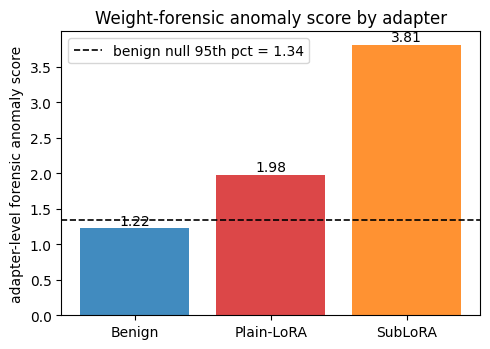

Saved figure -> results/figures/08_threeway_forensic_score.{pdf,png}


In [8]:
# ---- Figure: three-way adapter-level forensic score bar chart (paper money-shot) ----
fig, ax = plt.subplots(figsize=(5, 3.6))
names = list(ADAPTERS.keys())
scores = [adapter_score[n] for n in names]
colors = ['C0', 'C3', 'C1']
bars = ax.bar(names, scores, color=colors, alpha=0.85)
ax.axhline(threshold_95, color='k', ls='--', lw=1.2,
           label=f'benign null 95th pct = {threshold_95:.2f}')
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.05, f'{s:.2f}', ha='center', fontsize=10)
ax.set_ylabel('adapter-level forensic anomaly score')
ax.set_title('Weight-forensic anomaly score by adapter')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '08_threeway_forensic_score.pdf')
plt.savefig(FIGS / '08_threeway_forensic_score.png', dpi=150)
plt.show()
print('Saved figure -> results/figures/08_threeway_forensic_score.{pdf,png}')

In [9]:
# ---- Consolidated paper-ready summary ----
summary = {
    'n_layers': len(common),
    'mean_frobenius': {n: float(frob[n].mean()) for n in ADAPTERS},
    'mean_spectral_entropy': {n: float(sent[n].mean()) for n in ADAPTERS},
    'adapter_level_score': adapter_score,
    'threshold_95': threshold_95,
    'battery_vs_benign': battery,
    'per_layer_flag_rate': {r['adapter']: r['per_layer_flag_rate'] for r in rows},
}
with open(TABLES / '12_threeway_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=== PAPER-READY 3-WAY SUMMARY ===')
print(json.dumps(summary, indent=2))
print('\nSaved -> results/tables/12_threeway_summary.json')
print('Saved -> results/tables/10_sublora_vs_plain_battery.csv')
print('Saved -> results/tables/11_adapter_level_scores.csv')

=== PAPER-READY 3-WAY SUMMARY ===
{
  "n_layers": 112,
  "mean_frobenius": {
    "Benign": 0.28391527298039626,
    "Plain-LoRA": 0.46830981890005724,
    "SubLoRA": 0.4244848104592945
  },
  "mean_spectral_entropy": {
    "Benign": 2.5019171120865003,
    "Plain-LoRA": 2.4296481577413425,
    "SubLoRA": 2.1062170852507864
  },
  "adapter_level_score": {
    "Benign": 1.2240069953515704,
    "Plain-LoRA": 1.9807876277316123,
    "SubLoRA": 3.807881616235636
  },
  "threshold_95": 1.3388598470702067,
  "battery_vs_benign": {
    "Plain-LoRA": {
      "adapter": "Plain-LoRA",
      "mean_frobenius": 0.46830981890005724,
      "mean_spectral_entropy": 2.4296481577413425,
      "frob_wilcoxon_W": 0.0,
      "frob_wilcoxon_p": 4.096357955947718e-20,
      "frob_mannwhitney_U": 3147.0,
      "frob_mannwhitney_p": 1.1743586947427212e-10,
      "frob_cohens_d_paired": -2.087846885821698,
      "frob_cliffs_delta": -0.49824617346938777,
      "spectral_entropy_wilcoxon_W": 486.0,
      "spectra